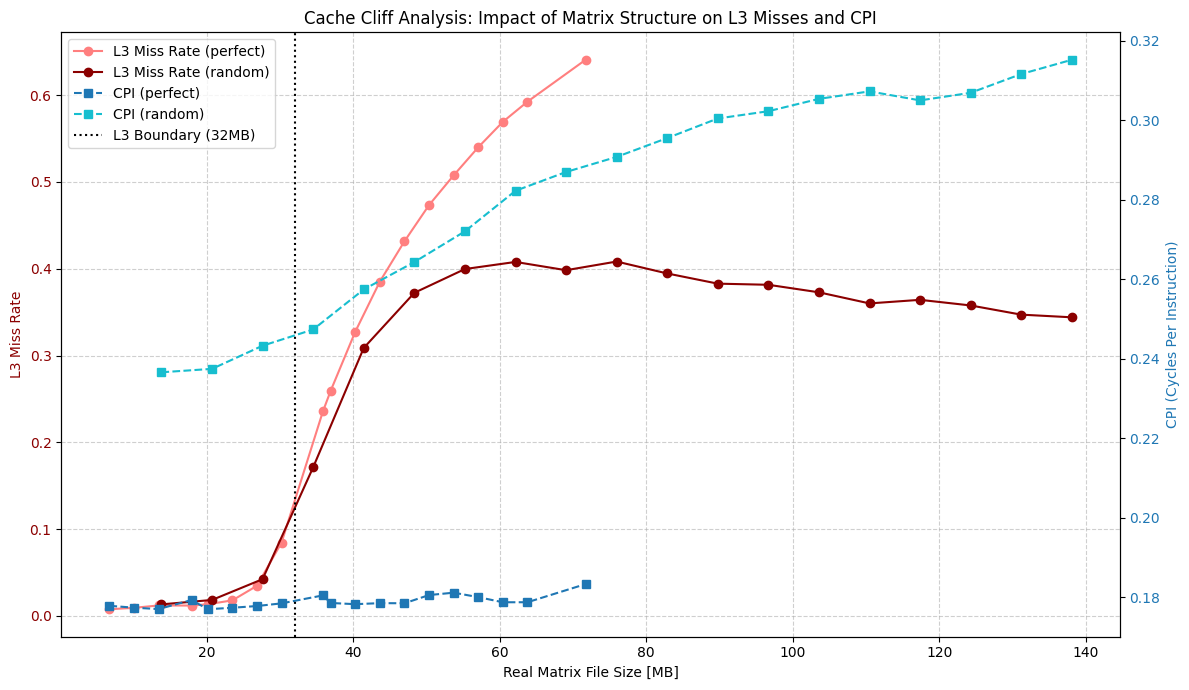

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Pfade definieren
csv_path = '/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_comparison_20260201_163704/summary.csv'
matrix_base_dir = '/home/mengelsl/MA-bench-framework/cachefit_testing/matrices'

df = pd.read_csv(csv_path)

# 2. Metriken berechnen
df['CPI'] = df['Clks'] / df['Inst']
# Vermeidung von Division durch Null bei der Miss Rate
df['MissRate'] = df['L3_Miss'] / (df['L3_Hit'] + df['L3_Miss']).replace(0, 1)

# 3. Median bilden (Gruppierung nach N und dem neuen Randomness-Faktor)
df_clean = df.groupby(['N', 'Randomness']).median(numeric_only=True).reset_index()

# 4. Dateigröße ermitteln (angepasst an das neue Namensschema: 0.5_N20000.bin)
def get_file_size(row):
    # Wir müssen sicherstellen, dass Randomness als String korrekt formatiert ist
    rand_val = f"{row['Randomness']:.1f}" if row['Randomness'] % 1 == 0 else str(row['Randomness'])
    # Falls dein Bash-Skript einfach nur den Float-String nutzt, reicht oft:
    rand_str = str(row['Randomness'])
    
    file_name = f"{rand_str}_N{int(row['N'])}.bin"
    file_path = os.path.join(matrix_base_dir, file_name)
    
    if os.path.exists(file_path):
        return os.path.getsize(file_path) / (1024**2) # MB
    return None

df_clean['MB'] = df_clean.apply(get_file_size, axis=1)
df_clean = df_clean.dropna(subset=['MB'])

# 5. Plotten
fig, ax1 = plt.subplots(figsize=(12, 7))

# Dynamische Farbwahl für verschiedene Randomness-Level
# Wir nehmen ein Mapping oder eine Farbskala
unique_r = sorted(df_clean['Randomness'].unique())
colors = plt.cm.viridis(unique_r) # Nutzt eine Farbskala von Gelb nach Lila

# --- Primäre Achse (Links): L3 Miss Rate ---
ax1.set_xlabel('Matrix File Size on Disk [MB]')
ax1.set_ylabel('L3 Miss Rate', color='darkred')

for r in unique_r:
    subset = df_clean[df_clean['Randomness'] == r]
    ax1.plot(subset['MB'], subset['MissRate'], 
             marker='o', linestyle='-', label=f'Miss Rate (R={r})')

ax1.tick_params(axis='y', labelcolor='darkred')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Sekundäre Achse (Rechts): CPI ---
ax2 = ax1.twinx()
ax2.set_ylabel('CPI (Cycles Per Instruction)', color='navy')

for r in unique_r:
    subset = df_clean[df_clean['Randomness'] == r]
    # Gestrichelte Linien für CPI zur besseren Unterscheidung
    ax2.plot(subset['MB'], subset['CPI'], 
             marker='s', linestyle='--', alpha=0.7, label=f'CPI (R={r})')

ax2.tick_params(axis='y', labelcolor='navy')

# Vertikale Linie für Cache-Limit (Zen 4 L3 ist oft 32MB)
plt.axvline(x=32, color='black', linestyle=':', linewidth=2, label='L3 Boundary (32MB)')

plt.title('Cache Cliff Analysis: Impact of Randomness Factor on L3 Performance')

# Legenden zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize='small', ncol=2)

fig.tight_layout()
plt.show()